In [19]:
from matplotlib import pyplot as plt
from matplotlib import colors
from matplotlib import patches 
import numpy as np
import pandas as pd
import sys
import os

In [20]:
# Statistics
def combinedError(group, field, se_field):
    N = group.size
    s = group[field].std()
    sigma_i = group[se_field]
    # combine in quadrature
    total_error = np.sqrt((s**2) / N + (sigma_i**2).sum() / (N**2))
    # total_error = s / np.sqrt(N)
    return pd.Series({
        "mean": group[field].mean(),
        "std": s,
        "mean_se": sigma_i.mean(),
        "error": total_error
    })
    
def getLinearFit(X, Y, error, minx = np.log(8)/8, n_largest_sizes = 3):
    fit = np.polyfit(X[-n_largest_sizes:], Y[-n_largest_sizes:], 1, w=1/error[-n_largest_sizes:]**2, cov=False)
    cov = ((0,0),(0,0))
    x = np.linspace(0, minx, 100)
    y = np.polyval(fit, x)
    return (x, y, cov[0][0])
    
def angleDependence(gamma):
        return (1 / 24) * (0
            + np.pi / gamma
            - gamma / np.pi
            + np.pi / (2*np.pi - gamma)
            - (2*np.pi - gamma) / np.pi
        )

def squareAngleDependence(gamma):
    return 2*angleDependence(gamma) + 2*angleDependence(np.pi - gamma)

In [21]:
# Get 2-point estimate for power laws
def getExponent(filename, col_name, se_name, 
                n=3, m=0,
                law="exp",
               skip=2):
    
    df_raw = pd.read_csv(filename, sep=',')
    df = (
        df_raw
        .sort_values(["L"])
        .groupby("L")[[col_name, se_name]]
        .apply(lambda x: combinedError(x, col_name, se_name))
        .reset_index()
    )
    
    lowest_size = df.shape[0]-skip-n-m
    X = np.zeros(n)
    Y = np.zeros(n)
    error = np.zeros(n)

    if law == "exp":
        df['logL'] = np.log(df['L'])
        df['1/L'] = 1/df['L']
        df['logX'] = np.log(df['mean'])
        df['SE_logX'] = df['error'] / df['mean']
        
        for i in range(lowest_size, lowest_size+n):
            X[i-lowest_size] = df['1/L'].iloc[i+skip]
            Y[i-lowest_size] = (df['logX'].iloc[i+skip] - df['logX'].iloc[i]) / (df['logL'].iloc[i+skip] - df['logL'].iloc[i])
            error[i-lowest_size] = (
                np.sqrt(
                    df['SE_logX'].iloc[i+skip]*df['SE_logX'].iloc[i+skip] + 
                    df['SE_logX'].iloc[i]*df['SE_logX'].iloc[i]) / 
                abs(df['logL'].iloc[i+skip] - df['logL'].iloc[i]))
            
    elif law == "b":
        df['l'] = df['L'] // 2
        df['logl'] = np.log(df['l'])
        df['logl/l'] = df['logl'] / df['l']
        
        for i in range(lowest_size, lowest_size+n):
            X[i-lowest_size] = df['logl/l'].iloc[i+skip]
            Y[i-lowest_size] = (df['mean'].iloc[i+skip] - df['mean'].iloc[i]) / (df['logl'].iloc[i+skip] - df['logl'].iloc[i])
            error[i - lowest_size] = (
                np.sqrt(
                    df['error'].iloc[i+skip] * df['error'].iloc[i+skip] +
                    df['error'].iloc[i]   * df['error'].iloc[i]) /
                abs(df['logl'].iloc[i+skip] - df['logl'].iloc[i]))
            
    return (X, Y, error)

In [22]:
# Plotting Functions
def plotFss(ax, X, Y, error, label, color, alpha=1):
    
    miny = min(Y)
    maxy = max(Y)
    ax.errorbar(X, Y, yerr=error, linestyle='--', fmt='.', capsize=3, color=color, label=label, alpha=alpha)
    
    return (miny, maxy)
    
def plotFssSpines(ax, yrange, xrange, yname, xname, expected=None, legend = True):

    ax.vlines((0,), yrange[0], yrange[1], linestyle='solid', color='black')
    if expected is not None:
        ax.hlines((expected,), xrange[0], xrange[1], linestyle='solid', color='red', label=f'Theory', alpha=0.5)
        # ax.hlines((0.343774677/8,), xrange[0], xrange[1], linestyle='solid', color='red', label=f'Theory (FK)', alpha=0.5)
        #ax.hlines((0.739320704/8,), xrange[0], xrange[1], linestyle='solid', color='black', label=f'Theory (Spin)', alpha=0.5)
    ax.set_ylim(yrange[0], yrange[1])
    ax.set_xlim(xrange[0], xrange[1])
    ax.set_xlabel(xname)
    ax.set_ylabel(yname)
    ax.set_title(f'FSS of {yname}') 
    if legend:
        ax.legend()

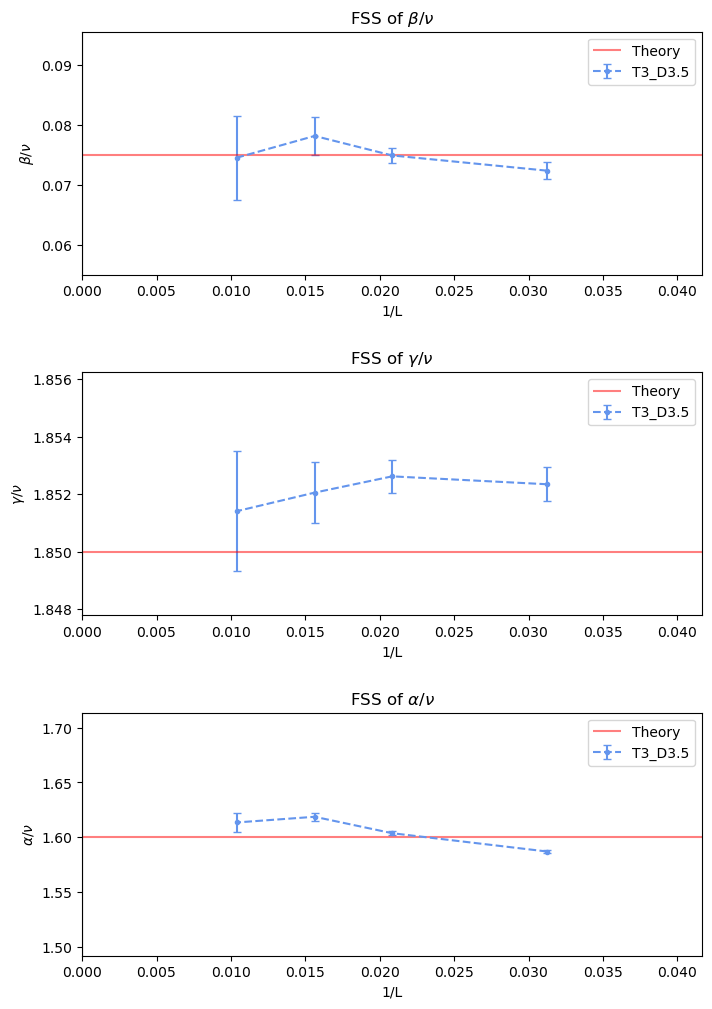

In [33]:
# Plotting Suite
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(8,12))
fig.subplots_adjust(hspace=0.4)
# axs=(axs, axs, axs)
lines = False
n = 4
m = 0
skip = 2
# A = squareAngleDependence(np.pi / 2)
A = 2
# root = '/projects/p32813/blume_capel/data/sweep'
root = '/projects/p32813/blume_capel/data/sweep'
dataset_ids = (0,)
datasets = (
    "t3_d3.5",
    "t3.5_d3.5X",
    "t3.5_d3",
    "t3_d3",
    "matrix",
)
# labels = (
#     "(0.6079750, 1.9659750)",
#     "(0.6079750, 1.9659875)",
#     "(0.6079750, 1.9659625)",
#     "(0.6079875, 1.9659750)",
#     "(0.6079625, 1.9659750)"
# )
labels = (
    "T3_D3.5",
    "T3.5_D3.5",
    "T3.5_D3",
    "T3_D3",
    "MATRIX",
)
colors = (
    'cornflowerblue',
    'green',
    'red',
    'black',
    'orange',
    
)
# -0.075, 1.85, 0.343774677 / 4
observables = [
    {
        "name": r"$\beta / \nu$",
        "filename": "magnet_f.txt",
        "col": ("m", "se_m"),
        "law": "exp",
        "expected": 0.075,
        "zoom": 3,
        "xmax": 1/24,
        "xname": "1/L",
        "sign": -1,
    },
    {
        "name": r"$\gamma / \nu$",
        "filename": "magnet.txt",
        "col": ("X", "se_X"),
        "law": "exp",
        "expected": 1.85,
        "zoom": 3,
        "xmax": 1/24,
        "xname": "1/L",
        "sign": 1,
    },
    {
        "name": r"$\alpha / \nu$",
        "filename": "energy.txt",
        "col": ("c", "se_c"),
        "law": "exp",
        "expected": 1.6,
        "zoom": 3,
        "xmax": 1/24,
        "xname": "1/L",
        "sign": 1
    },
    {
        "name": r"b",
        "filename": "gap/spin.txt",
        "col": ("corner_contribution", "standard_error"),
        "law": "b",
        "expected": 0.343774677/8,
        "zoom": 0.5,
        "xmax": np.log(12) / 12,
        "xname": r"$\log(\ell)/\ell$",
        "sign": 1,
    },
]
# 0.343774677
zooms = (0.3, 0.3, 0.5)
xmax = (1/16, 1/16, np.log(8)/8)
xnames = ("1/L", "1/L", r"$Log({\ell}) / \ell$")

for i in (0,1,2):
    obs = observables[i]
    miny = 100
    maxy = -100
    for j in dataset_ids:
        X, Y, err = getExponent(f"{root}/{datasets[j]}/{obs['filename']}", 
                                obs['col'][0], obs['col'][1],
                                n, m,
                                obs['law'], skip=skip)
        if obs['law'] == "b":
            X, Y, err = (X, Y / A, err / A)

        Y = Y * obs['sign']
    
        low, high = plotFss(axs[i], X, Y, err, labels[j], colors[j])
        # low, high = plotFss(axs[i], X, Y, err, "Spin", colors[j], 0.5)
        # plotFss(axs[i], X0, Y0, err0, "FK", 'orange', 0.5)
        # X0,Y0,err0 = (X,Y,err)
        miny = min(low, miny)
        maxy = max(high, maxy)
        if lines:
            linX, linY, _ = getLinearFit(X, Y, err, xmax[i], 3)
            axs[i].plot(linX, linY, color=colors[j], alpha=0.5)
    maxy = max(maxy, obs['expected'])
    dy = maxy - miny    
    
    
    
    plotFssSpines(axs[i], 
                  (miny-obs['zoom']*dy, maxy+obs['zoom']*dy), 
                  (0, obs['xmax']), 
                  obs['name'], obs['xname'], 
                  obs['expected'])
    
    '''plt.ylim(0,maxy+obs['zoom']*dy)
    plt.title(r"FSS of b for Line Segment")
    plt.legend(loc="lower right")'''

fig.show()
# 4_3.5, not looking good
# 4_3 inconclusive
# 3.5_3.5 looking maybe

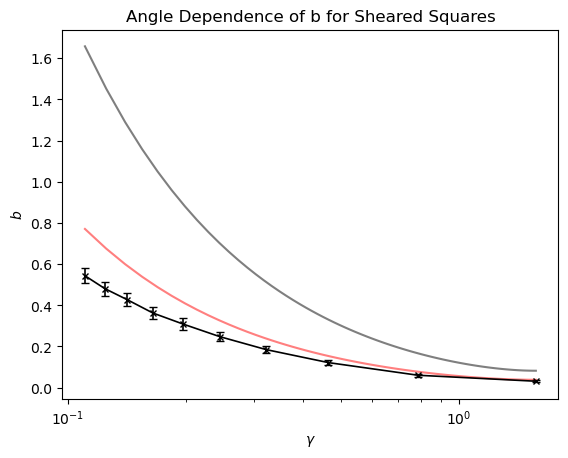

In [24]:
root = '/projects/p32813/blume_capel/data/sweep'
dirname = "gap/square/spin"
beta_expected = 0.343774677
beta_expected_spin = 0.739320704
datasets = (
    "t3_d3",
    "t3.5_d3",
    "t2.5_d3",
    "t3_d3.5",
    "t3_d2.5"
)
datasets = (
    "t3.5_d3",
    "t3_d3.5",
)
colors = (
    'green',
    'blue',
    'magenta',
    'orange',
    'black'
)
labels = (
    r"$\ell = 8-16$",
    r"$\ell = 12-24$",
    r"$\ell = 16-32$",
    r"$\ell = 24-48$",
    "Numerical Results",
    r"$\ell \rightarrow \infty$"
)
    
n_datasets = 2
n_points = 4
n_linear = 2
n_excluded = 0
n_gamma = 10

ls = (48, 32, 24, 16)
gammas = np.zeros(n_gamma)

def get_dataset_average_b(definition, fname):
    # Loop through different datasets for systematic error
    b_avg = np.zeros(n_points+1)
    b_err = np.zeros(n_points+1)
    b_sum = np.zeros(n_points+1)
    b_max = np.full(n_points+1, -100.0)
    b_min = np.full(n_points+1, 100.0)
    
    for j in range(n_datasets):
        path=f"{root}/{datasets[j]}/{fname}"
        X, Y, err = getExponent(path, definition, "standard_error",
                                    n_points, n_excluded, 'b')
        b_inf = getLinearFit(X, Y, err, n_largest_sizes=n_linear)[1][0]
        Y = np.append(Y, b_inf)

        # Loop through different 2-point estimates
        for k in range(n_points+1):
            b_sum[k] += Y[k]
            b_min[k] = min(b_min[k], Y[k])
            b_max[k] = max(b_max[k], Y[k])
            
    # Average and calculate systematic err
    for k in range(n_points+1):
        b_avg[k] = b_sum[k] / n_datasets
        b_err[k] = max(abs(b_max[k] - b_avg[k]), abs(b_avg[k] - b_min[k]))
    return (b_avg, b_err)
    
def get_sheared_square_series(definition):
    bs = np.zeros((n_points+1, n_gamma))
    errs = np.zeros((n_points+1, n_gamma))
    # Loop through all Gamma
    for i in range(n_gamma):
        fname = f"{dirname}/{i}.csv"
        gammas_path = f"{root}/{datasets[0]}/{fname}"
        gammas[i] = float(pd.read_csv(gammas_path)['gamma'].iloc[0]) * (np.pi / 180)
        b_avg, b_err = get_dataset_average_b(definition, fname)
        for k in range(n_points+1):
            bs[k,i] = b_avg[k]
            errs[k,i] = b_err[k]
        

        # # Loop through different datasets for systematic error
        # b_sum = np.zeros(n_points+1)
        # b_max = np.full(n_points+1, -100.0)
        # b_min = np.full(n_points+1, 100.0)
        # for j in range(n_datasets):
        #     fname = f"{root}/{datasets[j]}/{dirname}/{i}.csv"
        #     X, Y, err = getExponent(fname, definition, "standard_error",
        #                                 n_points, n_excluded, 'b')
        #     b_inf = getLinearFit(X, Y, err)[1][0]
        #     Y = np.append(Y, b_inf)
        #     # TEMP
            
                
        #     # Loop through different 2-point estimates
            
        #     for k in range(n_points+1):
        #         b_sum[k] += Y[k]
        #         b_min[k] = min(b_min[k], Y[k])
        #         if i == 9:
        #             print("but now: ", b_min[k])
        #         b_max[k] = max(b_max[k], Y[k])
                
        # # Average and calculate systematic err
        # for k in range(n_points+1):
        #     bs[k, i] = b_sum[k] / n_datasets
        #     errs[k, i] = max(abs(b_max[k] - bs[k, i]), abs(bs[k, i] - b_min[k]))

        


    return (bs, errs)


bs_cross, errs_cross = get_sheared_square_series("N_cross")
# bs_touch, errs_touch = get_sheared_square_series("N_touch")

# Plot all ls (crossed)
for k in range(n_points, n_points + 1):
    plt.errorbar(
        gammas, bs_cross[k], errs_cross[k],
        linestyle='-', linewidth=1.2,
        markersize=4, capsize=3, fillstyle='none',
        label=labels[k], marker="x", color=colors[k])

# Plot all ls (touched)
# for k in range(n_points + 1):
#     plt.errorbar(
#         gammas, bs_touch[k], errs_touch[k],
#         linestyle='-', linewidth=1.2,
#         markersize=4, capsize=3, fillstyle='none',
#         label=labels[k], marker="D", color=colors[k])

# Plot expected
X = np.linspace(gammas[n_gamma-1], gammas[0], 100)
plt.plot(X, beta_expected * squareAngleDependence(X), color = 'red', alpha=0.5, label = "Theory (FK)")
plt.plot(X, beta_expected_spin * squareAngleDependence(X), color = 'black', alpha=0.5, label="Theory (Spin)")
# plt.plot(X, beta_expected_spin * squareAngleDependence(X), color = 'gray', label="Expected")

# Plot extrapolated from gamma0

# plt.plot(X, (bs_cross[n_points, 0] / squareAngleDependence(gammas[0])) * squareAngleDependence(X), 
#          color = 'gray', label=fr"Geometric extrapolation from $\gamma = \pi / 2$")
# plt.fill_between(X, ((bs_cross[n_points, 0] + errs_cross[n_points,0]) / squareAngleDependence(gammas[0])) * squareAngleDependence(X),
#                 ((bs_cross[n_points, 0] - errs_cross[n_points,0]) / squareAngleDependence(gammas[0])) * squareAngleDependence(X), 
#                 color='gray', alpha=0.2)


from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = [
                   Line2D([0], [0], color="red", lw=4, label="Theory (FK)"),
                  ]
for k in range(n_points, n_points+1):
    legend_elements.append(Line2D([0], [0], color=colors[k], lw=4, label=labels[k]))

plt.xscale("log")
plt.xlabel(r"$\gamma$")
plt.ylabel(r"$b$")
plt.title("Angle Dependence of b for Sheared Squares")
# plt.legend(handles=legend_elements)
# plt.ylim(0, beta_expected * squareAngleDependence(gammas[n_gamma-1]))
plt.show()

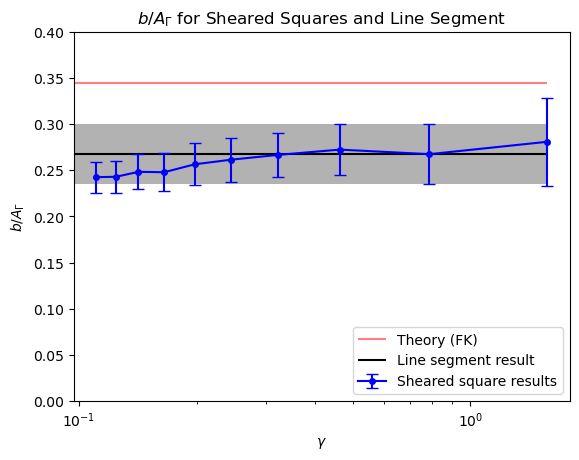

In [11]:
# Line segment
line_segment_fname = "gap/spin.txt"
ls_err = 0
ls_beta = 0
# Line segment
ls_sum = np.zeros(n_points+1)
ls_max = np.full(n_points+1, -100.0)
ls_min = np.full(n_points+1, 100.0)

ls_betas, ls_errs = get_dataset_average_b("corner_contribution", line_segment_fname)
ls_beta = ls_betas[n_points]*4
ls_err = ls_errs[n_points]*4
# for j in range(n_datasets):
#     fname = f"{root}/{datasets[j]}/{line_segment_fname}"
#     X, Y, err = getExponent(fname, "corner_contribution", "standard_error",
#                                 n_points, n_excluded, 'b')
#     bj = getLinearFit(X, Y, err)[1][0]
#     betaj = bj * 4
#     if j == 0:
#         ls_beta = betaj
#     ls_err = max(ls_err, abs(ls_beta - betaj))
    
# Sheared square (recycle from above)
betas = bs_cross[n_points] / squareAngleDependence(gammas)
beta_errs = errs_cross[n_points] / squareAngleDependence(gammas)

# Plot
plt.hlines(beta_expected, 0, np.pi/2, label="Theory (FK)", color="red", alpha=0.5)
# plt.hlines(beta_expected_spin, 0, np.pi/2, label="Theory (Spin)", color="black", alpha=0.5)
plt.hlines(ls_beta, 0, np.pi/2, label="Line segment result", color='black')
rect = patches.Rectangle((0, ls_beta - ls_err), np.pi/2, ls_err*2,  
                         edgecolor='none', linewidth=0.2,
                         facecolor='black', alpha=0.3)
plt.gca().add_patch(rect)
plt.errorbar(gammas, betas, beta_errs,
             color='blue', marker='.', markersize = 8, capsize = 4,
             label='Sheared square results')

plt.xscale("log")
plt.ylim(0,0.4)
plt.xlabel(r"$\gamma$")
plt.ylabel(r"$b/A_\Gamma$")
plt.title(r"$b/A_\Gamma$ for Sheared Squares and Line Segment")
plt.legend(loc="lower right")
plt.show()

1.8586527973641


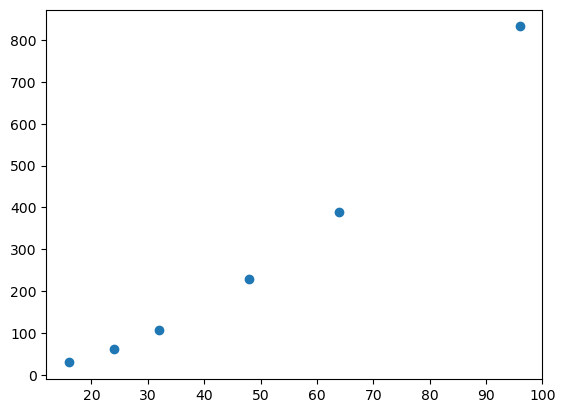

In [105]:
filename = "/projects/p32813/blume_capel/data/sweep/t3_d3.5/magnet.txt"
df_raw = pd.read_csv(filename, sep=',')
df = df_raw.groupby("L")[["X", "se_X"]].apply(lambda x: combinedError(x, "X", "se_X")).reset_index()
plt.scatter(df["L"], df["mean"])
# 2. Transform the data to log scale (natural log used here)
log_x = np.log(df["L"])
log_y = np.log(df["mean"])

# 3. Perform linear regression on the log-transformed data
# np.polyfit(x_data, y_data, degree) returns the coefficients [slope, intercept]
slope, intercept = np.polyfit(log_x, log_y, 1)
print(slope)
plt.show()

In [29]:
datasets = (
    "t3_d3",
    "t3.5_d3",
    "t2.5_d3",
    "t3_d3.5",
    "t3_d2.5"
)
for i in range(5):
    filename = f"/projects/p32813/blume_capel/data/sweep/{datasets[i]}/magnet.txt"
    df_raw = pd.read_csv(filename, sep=',')
    df = df_raw.groupby("L")[["X", "se_X"]].apply(lambda x: combinedError(x, "X", "se_X")).reset_index()
    print(datasets[i], df['mean'][5])

t3_d3 812.12074744
t3.5_d3 817.34046661
t2.5_d3 804.9249616100001
t3_d3.5 832.13543644
t3_d2.5 787.5730944199998
